# Graph Transformers and Graphormer

## Learning Objectives

1. **Motivate** graph transformers: standard GNNs are bounded by WL-1; attention over all pairs breaks the neighbourhood limit
2. **Define** the Graphormer encodings: centrality, spatial, and edge features
3. **Implement** the three Graphormer bias terms and show how they modify attention
4. **Demonstrate** on a small molecular graph why positional structure matters


## From GNNs to Graph Transformers

### Limitations of Standard GNNs

1. **Bounded expressiveness**: at most WL-1
2. **Over-smoothing**: deep GNNs collapse node embeddings
3. **Long-range dependencies**: K-hop neighbourhood grows exponentially but K must be small

A **Graph Transformer** applies self-attention over *all* node pairs, then uses graph structure as *bias* rather than as the aggregation mask.

### Graphormer (Ying et al., 2021)

Modify the standard transformer with three graph-aware encodings:

**1. Centrality Encoding**
$$h_v^0 = x_v + z^{\text{deg}^+(v)} + z^{\text{deg}^-(v)}$$
Embedding of in/out-degree as a node bias. Nodes with high degree get a different initial representation.

**2. Spatial Encoding**
$$A_{vw} \leftarrow A_{vw} + b_{\phi(v,w)}$$
where $\phi(v,w)$ is the shortest-path distance (SPD) between $v$ and $w$. This is added as a scalar bias to the attention logits: nearby nodes attend more strongly.

**3. Edge Encoding**
$$A_{vw} \leftarrow A_{vw} + \frac{1}{|\text{SP}(v,w)|} \sum_{e_i \in \text{SP}(v,w)} x_{e_i} \cdot w_i$$
Edge features along the shortest path are averaged and added to the attention logit.

### Modified Self-Attention

$$\text{Attn}(v, w) = \frac{(h_v W_Q)(h_w W_K)^\top}{\sqrt{d}} + b_{\phi(v,w)} + c_{e_{vw}}$$


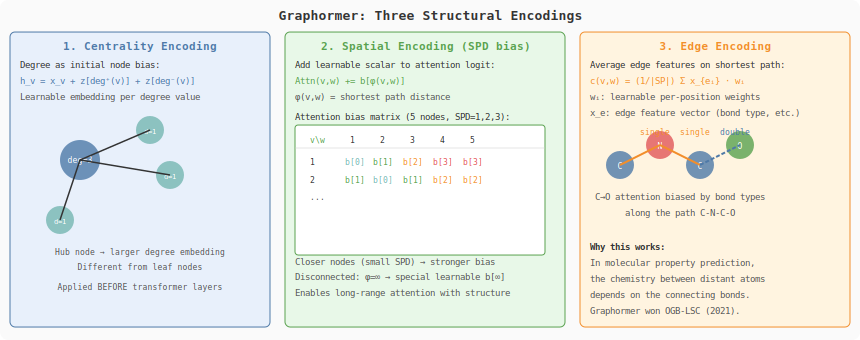

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="340" font-family="monospace" font-size="11">
  <rect width="860" height="340" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Graphormer: Three Structural Encodings</text>

  <!-- Centrality -->
  <rect x="10" y="32" width="260" height="295" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="140" y="50" text-anchor="middle" fill="#4e79a7" font-weight="bold">1. Centrality Encoding</text>
  <text x="20" y="68" fill="#333" font-size="9">Degree as initial node bias:</text>
  <text x="20" y="84" fill="#4e79a7" font-size="9">h_v = x_v + z[deg⁺(v)] + z[deg⁻(v)]</text>
  <text x="20" y="100" fill="#555" font-size="9">Learnable embedding per degree value</text>
  <!-- Mini graph with degree labels -->
  <circle cx="80" cy="160" r="20" fill="#4e79a7" opacity="0.8"/><text x="80" y="163" text-anchor="middle" fill="white" font-size="8">deg=3</text>
  <circle cx="150" cy="130" r="14" fill="#76b7b2" opacity="0.8"/><text x="150" y="134" text-anchor="middle" fill="white" font-size="7">d=1</text>
  <circle cx="170" cy="175" r="14" fill="#76b7b2" opacity="0.8"/><text x="170" y="179" text-anchor="middle" fill="white" font-size="7">d=1</text>
  <circle cx="60" cy="220" r="14" fill="#76b7b2" opacity="0.8"/><text x="60" y="224" text-anchor="middle" fill="white" font-size="7">d=1</text>
  <line x1="80" y1="160" x2="150" y2="130" stroke="#333" stroke-width="1.5"/>
  <line x1="80" y1="160" x2="170" y2="175" stroke="#333" stroke-width="1.5"/>
  <line x1="80" y1="160" x2="60" y2="220" stroke="#333" stroke-width="1.5"/>
  <text x="140" y="255" text-anchor="middle" fill="#555" font-size="8">Hub node → larger degree embedding</text>
  <text x="140" y="270" text-anchor="middle" fill="#555" font-size="8">Different from leaf nodes</text>
  <text x="140" y="290" text-anchor="middle" fill="#555" font-size="8">Applied BEFORE transformer layers</text>

  <!-- Spatial -->
  <rect x="285" y="32" width="280" height="295" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="425" y="50" text-anchor="middle" fill="#59a14f" font-weight="bold">2. Spatial Encoding (SPD bias)</text>
  <text x="295" y="68" fill="#333" font-size="9">Add learnable scalar to attention logit:</text>
  <text x="295" y="84" fill="#59a14f" font-size="9">Attn(v,w) += b[φ(v,w)]</text>
  <text x="295" y="100" fill="#555" font-size="9">φ(v,w) = shortest path distance</text>
  <!-- Attention matrix mock -->
  <text x="295" y="120" fill="#333" font-size="9">Attention bias matrix (5 nodes, SPD=1,2,3):</text>
  <rect x="295" y="125" width="250" height="130" rx="3" fill="#fff" stroke="#59a14f"/>
  <!-- Grid cells -->
  <text x="310" y="143" fill="#59a14f" font-size="8">v\w</text>
  <text x="350" y="143" fill="#333" font-size="8">1</text><text x="380" y="143" fill="#333" font-size="8">2</text><text x="410" y="143" fill="#333" font-size="8">3</text><text x="440" y="143" fill="#333" font-size="8">4</text><text x="470" y="143" fill="#333" font-size="8">5</text>
  <line x1="295" y1="148" x2="545" y2="148" stroke="#ccc" stroke-width="0.5"/>
  <text x="310" y="165" fill="#333" font-size="8">1</text><text x="345" y="165" fill="#76b7b2" font-size="8">b[0]</text><text x="373" y="165" fill="#59a14f" font-size="8">b[1]</text><text x="403" y="165" fill="#f28e2b" font-size="8">b[2]</text><text x="433" y="165" fill="#e15759" font-size="8">b[3]</text><text x="463" y="165" fill="#e15759" font-size="8">b[3]</text>
  <text x="310" y="183" fill="#333" font-size="8">2</text><text x="345" y="183" fill="#59a14f" font-size="8">b[1]</text><text x="373" y="183" fill="#76b7b2" font-size="8">b[0]</text><text x="403" y="183" fill="#59a14f" font-size="8">b[1]</text><text x="433" y="183" fill="#f28e2b" font-size="8">b[2]</text><text x="463" y="183" fill="#f28e2b" font-size="8">b[2]</text>
  <text x="310" y="200" fill="#555" font-size="8">...</text>
  <text x="295" y="265" fill="#555" font-size="9">Closer nodes (small SPD) → stronger bias</text>
  <text x="295" y="280" fill="#555" font-size="9">Disconnected: φ=∞ → special learnable b[∞]</text>
  <text x="295" y="296" fill="#555" font-size="9">Enables long-range attention with structure</text>

  <!-- Edge encoding -->
  <rect x="580" y="32" width="270" height="295" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="715" y="50" text-anchor="middle" fill="#f28e2b" font-weight="bold">3. Edge Encoding</text>
  <text x="590" y="68" fill="#333" font-size="9">Average edge features on shortest path:</text>
  <text x="590" y="84" fill="#f28e2b" font-size="9">c(v,w) = (1/|SP|) Σ x_{eᵢ} · wᵢ</text>
  <text x="590" y="100" fill="#555" font-size="9">wᵢ: learnable per-position weights</text>
  <text x="590" y="116" fill="#555" font-size="9">x_e: edge feature vector (bond type, etc.)</text>
  <!-- Example molecule path -->
  <circle cx="620" cy="165" r="14" fill="#4e79a7" opacity="0.8"/><text x="620" y="169" text-anchor="middle" fill="white" font-size="8">C</text>
  <circle cx="660" cy="145" r="14" fill="#e15759" opacity="0.8"/><text x="660" y="149" text-anchor="middle" fill="white" font-size="8">N</text>
  <circle cx="700" cy="165" r="14" fill="#4e79a7" opacity="0.8"/><text x="700" y="169" text-anchor="middle" fill="white" font-size="8">C</text>
  <circle cx="740" cy="145" r="14" fill="#59a14f" opacity="0.8"/><text x="740" y="149" text-anchor="middle" fill="white" font-size="8">O</text>
  <line x1="620" y1="165" x2="660" y2="145" stroke="#f28e2b" stroke-width="2"/>
  <line x1="660" y1="145" x2="700" y2="165" stroke="#f28e2b" stroke-width="2"/>
  <line x1="700" y1="165" x2="740" y2="145" stroke="#4e79a7" stroke-width="2" stroke-dasharray="4,2"/>
  <text x="640" y="135" fill="#f28e2b" font-size="8">single</text>
  <text x="680" y="135" fill="#f28e2b" font-size="8">single</text>
  <text x="720" y="135" fill="#4e79a7" font-size="8">double</text>
  <text x="680" y="200" text-anchor="middle" fill="#555" font-size="9">C→O attention biased by bond types</text>
  <text x="680" y="216" text-anchor="middle" fill="#555" font-size="9">along the path C-N-C-O</text>
  <text x="590" y="250" fill="#333" font-size="9" font-weight="bold">Why this works:</text>
  <text x="590" y="266" fill="#555" font-size="9">In molecular property prediction,</text>
  <text x="590" y="282" fill="#555" font-size="9">the chemistry between distant atoms</text>
  <text x="590" y="298" fill="#555" font-size="9">depends on the connecting bonds.</text>
  <text x="590" y="314" fill="#555" font-size="9">Graphormer won OGB-LSC (2021).</text>
</svg>
'''
display(SVG(svg))


In [2]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import deque


def bfs_distances(adj_list, src):
    """BFS shortest-path distances from src to all nodes."""
    n = len(adj_list)
    dist = [-1] * n
    dist[src] = 0
    q = deque([src])
    while q:
        v = q.popleft()
        for u in adj_list[v]:
            if dist[u] == -1:
                dist[u] = dist[v] + 1
                q.append(u)
    return dist


def spd_matrix(adj_list):
    """Full pairwise shortest-path distance matrix."""
    n = len(adj_list)
    D = np.zeros((n, n), dtype=int)
    for v in range(n):
        dists = bfs_distances(adj_list, v)
        for u in range(n):
            D[v, u] = dists[u] if dists[u] >= 0 else 999
    return D


class GraphormerAttention:
    """
    One head of Graphormer self-attention (forward pass only).
    Attn(v,w) = (Q[v] · K[w]) / sqrt(d) + spatial_bias[phi(v,w)]
    """

    def __init__(self, d_model, max_dist=10, seed=0):
        rng = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(d_model)
        self.W_Q = rng.normal(0, scale, (d_model, d_model))
        self.W_K = rng.normal(0, scale, (d_model, d_model))
        self.W_V = rng.normal(0, scale, (d_model, d_model))
        # Spatial bias: one scalar per distance bucket (0..max_dist, + inf bucket)
        self.b_spatial = rng.normal(0, 0.1, max_dist + 2)
        self.d = d_model
        self.max_dist = max_dist

    def forward(self, H, SPD):
        n = H.shape[0]
        Q = H @ self.W_Q   # (n, d)
        K = H @ self.W_K
        V = H @ self.W_V

        # Raw dot-product attention logits
        logits = (Q @ K.T) / np.sqrt(self.d)   # (n, n)

        # Spatial bias
        for v in range(n):
            for w in range(n):
                d = SPD[v, w]
                idx = min(d, self.max_dist + 1)
                logits[v, w] += self.b_spatial[idx]

        # Softmax
        logits -= logits.max(1, keepdims=True)
        attn = np.exp(logits)
        attn /= attn.sum(1, keepdims=True)

        return attn @ V, attn


# ── Demo: small molecular graph (benzene-like 6-cycle) ────────────────────────
n = 6
adj = [[1, 5], [0, 2], [1, 3], [2, 4], [3, 5], [4, 0]]
rng = np.random.default_rng(7)
H   = rng.normal(0, 0.5, (n, 8))
SPD = spd_matrix(adj)

print("Shortest-path distance matrix (benzene 6-cycle):")
print(SPD)
print()

attn_layer = GraphormerAttention(d_model=8, seed=42)
out, attn = attn_layer.forward(H, SPD)

print("Attention weights (row = query node, col = key node):")
np.set_printoptions(precision=3, suppress=True)
print(attn)


Shortest-path distance matrix (benzene 6-cycle):
[[0 1 2 3 2 1]
 [1 0 1 2 3 2]
 [2 1 0 1 2 3]
 [3 2 1 0 1 2]
 [2 3 2 1 0 1]
 [1 2 3 2 1 0]]

Attention weights (row = query node, col = key node):
[[0.15  0.199 0.147 0.166 0.154 0.183]
 [0.19  0.153 0.201 0.155 0.156 0.144]
 [0.127 0.173 0.147 0.263 0.145 0.145]
 [0.137 0.141 0.181 0.197 0.195 0.149]
 [0.138 0.138 0.16  0.219 0.168 0.178]
 [0.179 0.16  0.14  0.159 0.197 0.165]]


In [3]:
# ── Effect of spatial bias on attention pattern ───────────────────────────────
# Compare attention WITH vs WITHOUT spatial bias

class VanillaAttention:
    def __init__(self, d_model, seed=0):
        rng = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(d_model)
        self.W_Q = rng.normal(0, scale, (d_model, d_model))
        self.W_K = rng.normal(0, scale, (d_model, d_model))
        self.W_V = rng.normal(0, scale, (d_model, d_model))
        self.d = d_model

    def forward(self, H):
        Q = H @ self.W_Q
        K = H @ self.W_K
        V = H @ self.W_V
        logits = Q @ K.T / np.sqrt(self.d)
        logits -= logits.max(1, keepdims=True)
        attn = np.exp(logits)
        attn /= attn.sum(1, keepdims=True)
        return attn @ V, attn


# Use same Q/K weights
van   = VanillaAttention(d_model=8, seed=42)
graph = GraphormerAttention(d_model=8, seed=42)

_, attn_van   = van.forward(H)
_, attn_graph = graph.forward(H, SPD)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, attn_mat, title in zip(
    axes,
    [attn_van, attn_graph],
    ["Vanilla Transformer (no graph bias)",
     "Graphormer (with SPD spatial bias)"]
):
    im = ax.imshow(attn_mat, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Key node")
    ax.set_ylabel("Query node")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("graphormer_attention.png", dpi=110)
plt.show()
print("Saved graphormer_attention.png")

print()
print("With spatial bias: nearby nodes (SPD=1) get stronger attention.")
print("Vanilla transformer: attention driven only by feature similarity.")


Saved graphormer_attention.png

With spatial bias: nearby nodes (SPD=1) get stronger attention.
Vanilla transformer: attention driven only by feature similarity.


/tmp/ipykernel_305937/5725837.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

| Encoding | What it captures | How added |
|---|---|---|
| Centrality | Node importance (degree) | Node embedding before layer 0 |
| Spatial (SPD) | Graph distance between pair | Bias on attention logit |
| Edge | Chemistry of path between pair | Bias on attention logit |

**Graph Transformers** move the structural inductive bias from the aggregation rule (GNN) to the attention mechanism. This allows:
- Attending to any node pair (not just neighbours)
- Long-range information exchange
- Richer expressiveness beyond WL-1

**Applications**: molecular property prediction (PCQM4Mv2), protein structure (initial steps before AlphaFold2's Evoformer), knowledge graph completion.
